## Classification with PyTorch

In [7]:
import sklearn
from sklearn.datasets import make_circles, make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from torch import nn
import requests
from pathlib import Path
import torchmetrics

In [8]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=67)

In [9]:
len(X), len(y)

(1000, 1000)

In [10]:
circles = pd.DataFrame({"X1" : X[: , 0],
                        "X2" : X[:,1],
                        "label" : y})
circles.head()

,X1,X2,label
0,0.233230,0.810821,1
1,0.175660,-1.000523,0
2,-0.606525,0.544122,1
3,0.453224,-0.673099,1
4,0.133497,0.836877,1


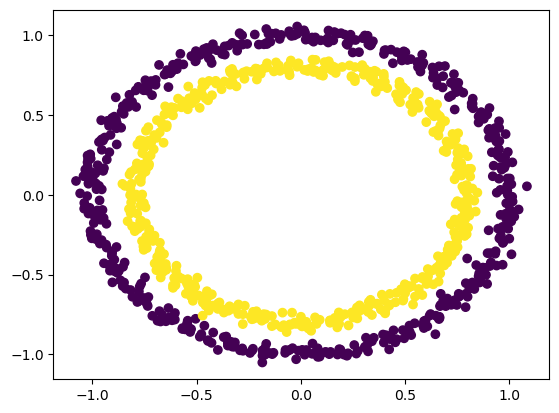

In [11]:
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y)
plt.show()

In [12]:
## Convert our data into tensors

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [13]:
type(X),type(y),X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [14]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 , random_state= 67)

In [15]:
#Device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [16]:
#Creating a model

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features= 2, out_features= 5)
    self.layer_2 = nn.Linear(in_features= 5, out_features= 1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))
  
model_0  = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
#Create same model as above with nn.sequential

model_0 = nn.Sequential(
  nn.Linear(in_features= 2, out_features= 5),
  nn.Linear(in_features=5, out_features= 1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3107, -0.7044],
                      [-0.2455, -0.5784],
                      [ 0.3316, -0.1274],
                      [ 0.3880, -0.3719],
                      [-0.6822, -0.2603]])),
             ('0.bias', tensor([-0.3500, -0.2060, -0.5402, -0.1578, -0.1812])),
             ('1.weight',
              tensor([[ 0.0570,  0.1217, -0.1773, -0.3717, -0.3355]])),
             ('1.bias', tensor([0.1624]))])

In [19]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
untrained_preds

tensor([[0.2429],
        [0.3057],
        [0.2844],
        [0.4198],
        [0.4719],
        [0.3793],
        [0.4201],
        [0.4286],
        [0.2526],
        [0.2334],
        [0.3124],
        [0.4239],
        [0.2087],
        [0.2151],
        [0.3957],
        [0.4400],
        [0.4397],
        [0.4278],
        [0.2313],
        [0.2053],
        [0.2891],
        [0.3699],
        [0.4683],
        [0.4661],
        [0.3477],
        [0.2845],
        [0.4391],
        [0.3324],
        [0.3334],
        [0.4279],
        [0.2255],
        [0.2491],
        [0.4258],
        [0.2239],
        [0.2360],
        [0.4473],
        [0.2552],
        [0.4078],
        [0.4393],
        [0.3113],
        [0.4163],
        [0.2801],
        [0.2872],
        [0.4184],
        [0.4380],
        [0.4608],
        [0.3829],
        [0.4295],
        [0.3187],
        [0.3888],
        [0.4047],
        [0.3054],
        [0.4445],
        [0.3729],
        [0.3083],
        [0

In [20]:
## Setup loss functions and optimizer

loss_fn = nn.BCEWithLogitsLoss() #Cuz classification problem

optimizer = torch.optim.SGD(params= model_0.parameters(), lr = 0.1)

In [21]:
def accuracy_fn(y_true, y_preds):
  correct = torch.eq(y_true,y_preds).sum().item()
  acc = (correct/len(y_preds)) * 100
  return acc

In [22]:
##We now need to create the training loop for our model

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test[:5].to(device))
y_logits

tensor([[0.2429],
        [0.3057],
        [0.2844],
        [0.4198],
        [0.4719]])

In [23]:
y_test[:5]

tensor([1., 1., 1., 0., 0.])

In [24]:
## We use the sigmoid activation function on our model's logits(raw predictions out of the neural network) to turn them into prediction probabilites

y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.5604],
        [0.5758],
        [0.5706],
        [0.6034],
        [0.6158]])

In [25]:
y_preds = torch.round(y_preds_probs)
y_preds

#in one line

y_preds_labels = torch.round(torch.sigmoid(model_0(X_test[:5].to(device))))

In [26]:
print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.])

In [27]:
## Create a training loop

torch.manual_seed(67)

epochs = 100

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ##Training
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train) ## here loss function is BCE with Logits so we expect logits as inputs rather then y_preds
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  #Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70850, Accuracy: 49.50% | Test Loss: 0.70424, Test acc: 52.00%
Epoch: 10 | Loss: 0.69913, Accuracy: 49.50% | Test Loss: 0.69696, Test acc: 52.00%
Epoch: 20 | Loss: 0.69545, Accuracy: 49.50% | Test Loss: 0.69457, Test acc: 52.00%
Epoch: 30 | Loss: 0.69398, Accuracy: 49.50% | Test Loss: 0.69394, Test acc: 52.00%
Epoch: 40 | Loss: 0.69338, Accuracy: 57.75% | Test Loss: 0.69391, Test acc: 54.50%
Epoch: 50 | Loss: 0.69313, Accuracy: 52.62% | Test Loss: 0.69405, Test acc: 47.50%
Epoch: 60 | Loss: 0.69302, Accuracy: 51.38% | Test Loss: 0.69423, Test acc: 47.00%
Epoch: 70 | Loss: 0.69297, Accuracy: 50.75% | Test Loss: 0.69439, Test acc: 45.00%
Epoch: 80 | Loss: 0.69295, Accuracy: 50.12% | Test Loss: 0.69453, Test acc: 45.50%
Epoch: 90 | Loss: 0.69293, Accuracy: 49.62% | Test Loss: 0.69464, Test acc: 46.50%


In [28]:
if Path("helper_functions.py").is_file():
  print("Already downloaded! Skipping downloading.")
else:
  print("Downloading Helper functions")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions , plot_decision_boundary

Already downloaded! Skipping downloading.


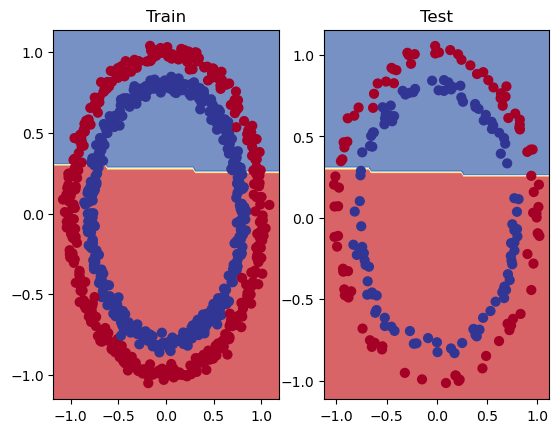

In [29]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [30]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features= 2, out_features= 10)
    self.layer2 = nn.Linear(in_features=10, out_features= 10)
    self.layer3 = nn.Linear(in_features= 10, out_features= 1)
  
  def forward(self,x):
    return self.layer3(self.layer2(self.layer1(x)))
  
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [31]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [32]:
torch.manual_seed(67)

epochs = 1000

X_train,y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()


  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch %100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72312, Accuracy: 42.00% | Test Loss: 0.72065, Test acc: 42.00%
Epoch: 100 | Loss: 0.69311, Accuracy: 43.75% | Test Loss: 0.69388, Test acc: 41.00%
Epoch: 200 | Loss: 0.69293, Accuracy: 50.00% | Test Loss: 0.69495, Test acc: 40.50%
Epoch: 300 | Loss: 0.69291, Accuracy: 49.25% | Test Loss: 0.69514, Test acc: 44.50%
Epoch: 400 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69520, Test acc: 46.00%
Epoch: 500 | Loss: 0.69291, Accuracy: 49.75% | Test Loss: 0.69521, Test acc: 45.50%
Epoch: 600 | Loss: 0.69291, Accuracy: 49.75% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 700 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 800 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 900 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69523, Test acc: 46.00%


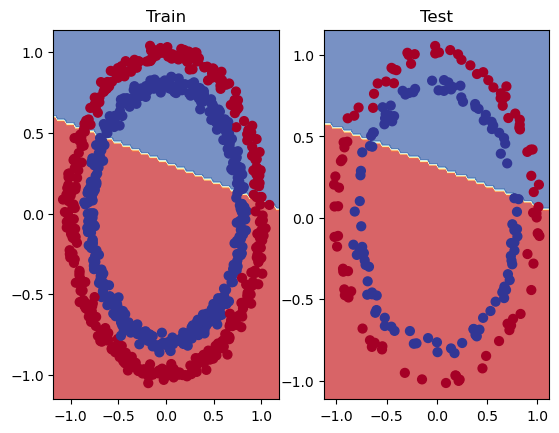

In [33]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [34]:
## Test our data on the older dataset

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression= torch.arange(start,end,step).unsqueeze(dim= 1)
y_regression = weight * X_regression + bias

In [35]:
X_train_regression , y_train_regression = X_regression[:80], y_regression[:80]
X_test_regression , y_test_regression = X_regression[80:], y_regression[80:]

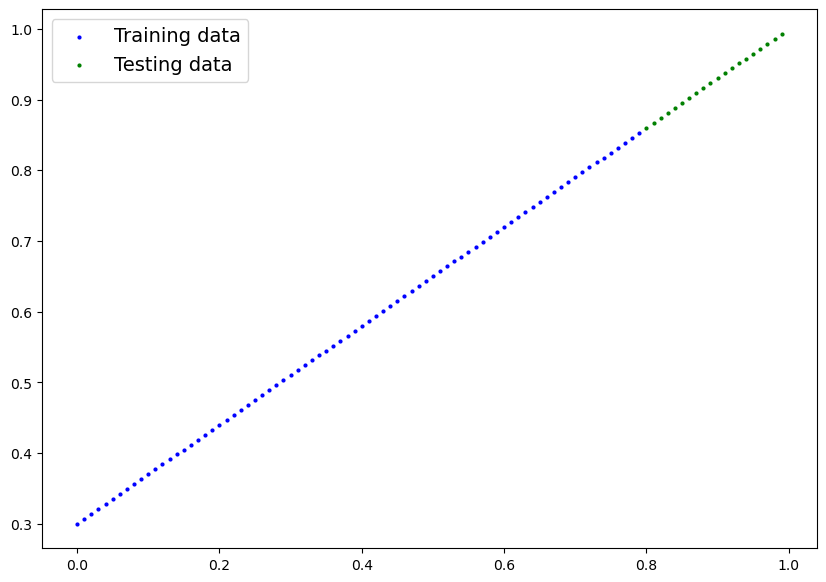

In [36]:
plot_predictions(train_data= X_train_regression, train_labels= y_train_regression, test_data= X_test_regression, test_labels= y_test_regression)

In [37]:
model_2 = nn.Sequential(
  nn.Linear(in_features= 1, out_features= 10),
  nn.Linear(in_features= 10, out_features= 10),
  nn.Linear(in_features= 10, out_features= 1)
).to(device)

In [38]:
loss_fn = nn.L1Loss()
optimizer= torch.optim.SGD(params= model_2.parameters(), lr = 0.01)

In [39]:
torch.manual_seed(67)

epochs = 1000

X_train_regression, y_train_regression, X_test_regression, y_test_regression = X_train_regression.to(device), y_train_regression.to(device), X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()

  y_preds = model_2(X_train_regression)
  loss = loss_fn(y_preds, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_preds = model_2(X_test_regression)
    test_loss = loss_fn(test_preds, y_test_regression)
  
  if epoch %100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.34239 | Test Loss: 0.78109
Epoch: 100 | Loss: 0.09769 | Test Loss: 0.23916
Epoch: 200 | Loss: 0.02965 | Test Loss: 0.01220
Epoch: 300 | Loss: 0.01467 | Test Loss: 0.03679
Epoch: 400 | Loss: 0.01631 | Test Loss: 0.04029
Epoch: 500 | Loss: 0.01554 | Test Loss: 0.03970
Epoch: 600 | Loss: 0.01486 | Test Loss: 0.03796
Epoch: 700 | Loss: 0.01492 | Test Loss: 0.03813
Epoch: 800 | Loss: 0.01430 | Test Loss: 0.03675
Epoch: 900 | Loss: 0.01458 | Test Loss: 0.03640


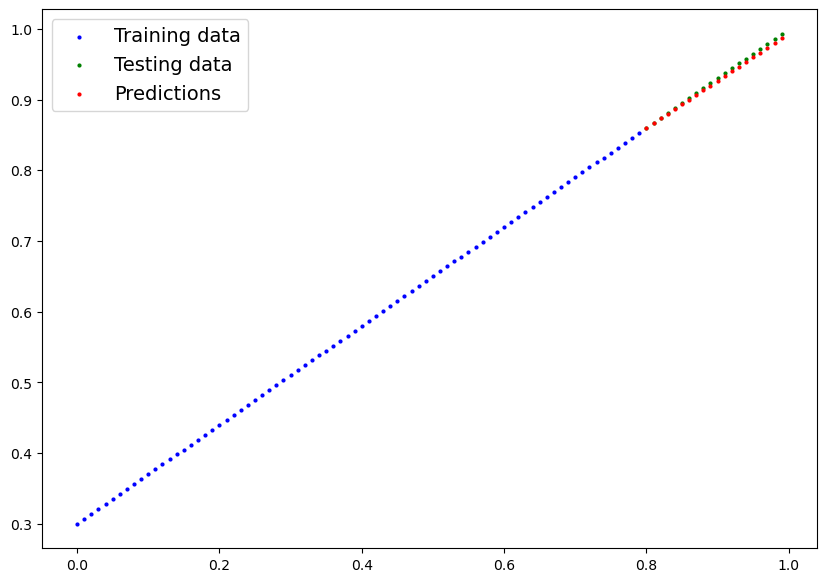

In [40]:
model_2.eval()

with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data= X_train_regression, train_labels=  y_train_regression, test_data= X_test_regression, test_labels= y_test_regression, predictions= y_preds)

In [41]:
## This means we need to add non-linearity into our model

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features= 2, out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3 = nn.Linear(in_features=10, out_features= 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
  
model_3 = CircleModelV2().to(device)

In [42]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params= model_3.parameters(), lr = 0.1)

In [43]:
torch.manual_seed(67)

epochs = 1500

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn (y_true= y_train, y_preds= y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_preds= test_preds, y_true= y_test)

  if epoch%100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71383, Accuracy: 50.50% | Test Loss: 0.71798, Test acc: 48.00%
Epoch: 100 | Loss: 0.69183, Accuracy: 49.75% | Test Loss: 0.68847, Test acc: 53.00%
Epoch: 200 | Loss: 0.68956, Accuracy: 51.25% | Test Loss: 0.68508, Test acc: 57.00%
Epoch: 300 | Loss: 0.68719, Accuracy: 51.62% | Test Loss: 0.68176, Test acc: 57.00%
Epoch: 400 | Loss: 0.68420, Accuracy: 52.75% | Test Loss: 0.67812, Test acc: 58.00%
Epoch: 500 | Loss: 0.68013, Accuracy: 55.00% | Test Loss: 0.67363, Test acc: 58.50%
Epoch: 600 | Loss: 0.67357, Accuracy: 56.12% | Test Loss: 0.66674, Test acc: 58.00%
Epoch: 700 | Loss: 0.66213, Accuracy: 58.63% | Test Loss: 0.65461, Test acc: 61.50%
Epoch: 800 | Loss: 0.64039, Accuracy: 79.50% | Test Loss: 0.63317, Test acc: 81.00%
Epoch: 900 | Loss: 0.59880, Accuracy: 92.12% | Test Loss: 0.58979, Test acc: 90.50%
Epoch: 1000 | Loss: 0.52146, Accuracy: 96.50% | Test Loss: 0.50982, Test acc: 96.50%
Epoch: 1100 | Loss: 0.39957, Accuracy: 99.00% | Test Loss: 0.38463, Test acc:

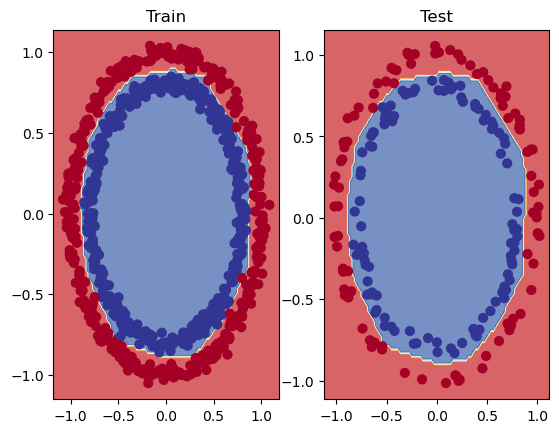

In [44]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [45]:
#--------------------

A = torch.arange(-10,10,1, dtype= torch.float)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

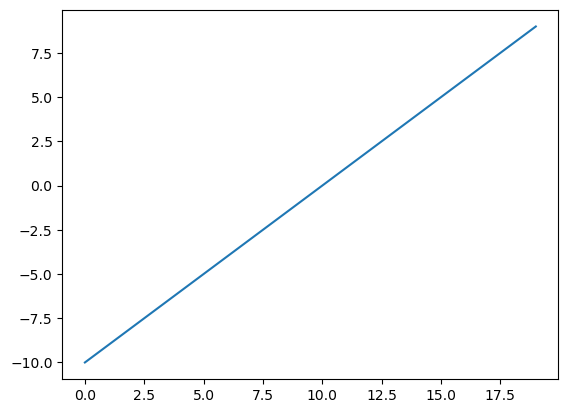

In [46]:
plt.plot(A)

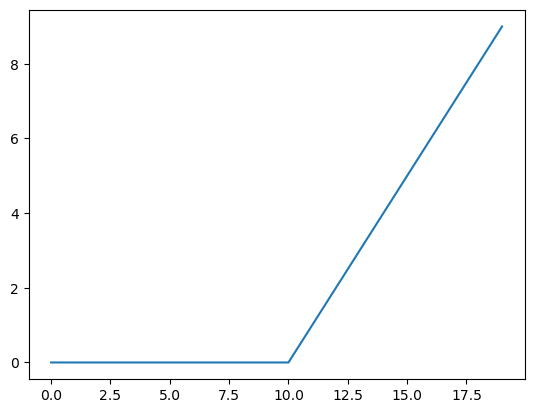

In [47]:
plt.plot(torch.relu(A))

In [48]:
def relu(x):
  return torch.max(torch.tensor(0), x)

In [49]:
def sigmoid(x):
  return 1/(1+ torch.exp(-x))

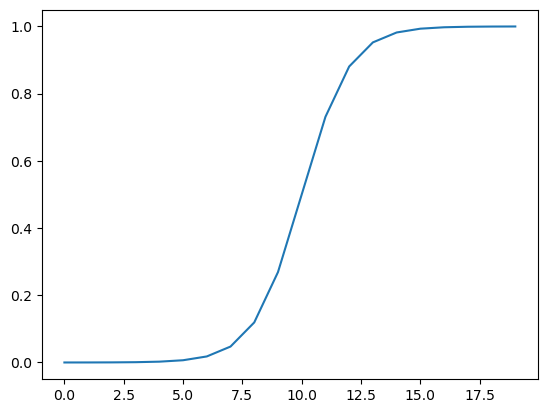

In [50]:
plt.plot(torch.sigmoid(A))

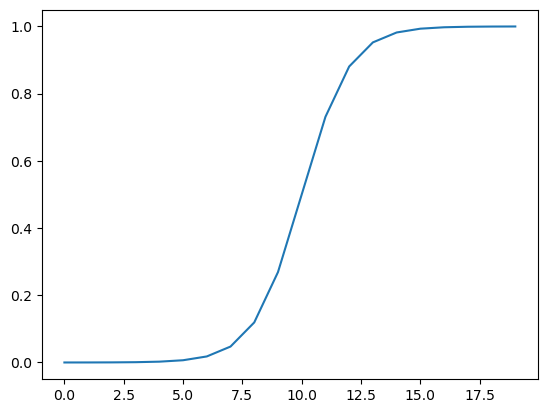

In [51]:
plt.plot(sigmoid(A))

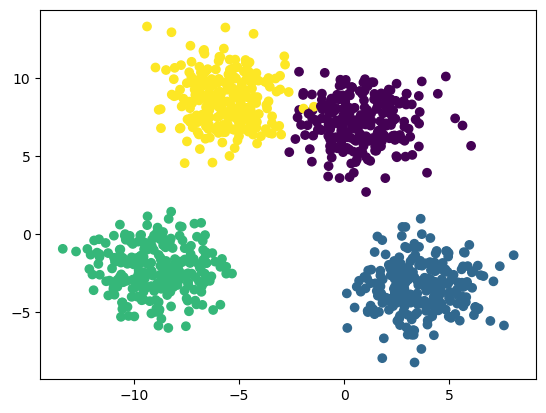

In [52]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 67

X_blob, y_blob = make_blobs(n_samples= 1000, n_features= NUM_FEATURES, centers= NUM_CLASSES, cluster_std = 1.5, random_state= RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size= 0.2, random_state= RANDOM_SEED)

plt.scatter(X_blob[:,0],X_blob[:,1], c= y_blob)

In [53]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [54]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features= input_features, out_features= hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features= hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)
  
model_4 = BlobModel(input_features= 2, output_features= 4, hidden_units= 8).to(device)

In [55]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [56]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_pred_probs = torch.softmax(y_logits,dim= 1)
y_logits[:5], y_pred_probs[:5]

(tensor([[-0.7671, -0.4094, -0.9291,  0.2305],
         [-0.5631,  0.0306, -0.4352, -0.1089],
         [-0.9091, -0.5332, -1.0494,  0.2913],
         [-0.3523,  0.0286,  0.3701,  0.2866],
         [-0.7015, -0.1303, -0.6007, -0.0126]]),
 tensor([[0.1669, 0.2387, 0.1419, 0.4525],
         [0.1811, 0.3279, 0.2058, 0.2852],
         [0.1505, 0.2191, 0.1308, 0.4997],
         [0.1558, 0.2281, 0.3209, 0.2952],
         [0.1704, 0.3017, 0.1885, 0.3394]]))

In [57]:
torch.argmax(y_pred_probs[0])

tensor(3)

In [58]:
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([3, 1, 3, 2, 3, 3, 1, 3, 3, 3, 3, 3, 1, 2, 1, 1, 3, 1, 3, 3, 3, 3, 3, 3,
        2, 1, 1, 3, 1, 3, 3, 1, 2, 3, 2, 1, 1, 2, 1, 3, 3, 1, 1, 1, 1, 3, 1, 1,
        3, 3, 1, 3, 1, 2, 3, 1, 1, 3, 1, 3, 3, 3, 3, 3, 1, 2, 3, 1, 3, 1, 3, 3,
        3, 1, 1, 1, 1, 3, 3, 1, 3, 3, 3, 3, 1, 1, 3, 2, 3, 3, 3, 3, 3, 3, 3, 1,
        1, 3, 3, 2, 1, 3, 1, 1, 2, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 3, 3, 3, 1,
        3, 1, 3, 1, 2, 3, 1, 1, 3, 3, 1, 1, 1, 3, 3, 2, 1, 3, 3, 1, 3, 3, 1, 3,
        3, 3, 3, 3, 3, 3, 1, 2, 1, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 1, 1, 3, 3, 2,
        3, 2, 3, 1, 1, 3, 3, 3, 1, 3, 3, 1, 3, 1, 1, 3, 3, 1, 3, 3, 1, 3, 1, 1,
        3, 1, 3, 3, 3, 3, 3, 3])

In [59]:
torch.manual_seed(RANDOM_SEED)

epochs = 100

X_blob_train , X_blob_test, y_blob_train, y_blob_test = X_blob_train.to(device), X_blob_test.to(device), y_blob_train.to(device).long(),y_blob_test.to(device).long()

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred_probs = torch.softmax(y_logits, dim= 1)
  y_preds = torch.argmax(y_pred_probs, dim= 1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train, y_preds= y_preds) 

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_4.eval()

  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred_probs = torch.softmax(test_logits, dim=1)
    test_preds = torch.argmax(test_pred_probs, dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true= y_blob_test, y_preds= test_preds)

  if epoch%10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.50740, Accuracy: 26.88% | Test Loss: 1.33674, Test acc: 37.00%
Epoch: 10 | Loss: 0.94558, Accuracy: 50.25% | Test Loss: 0.91108, Test acc: 49.50%
Epoch: 20 | Loss: 0.75540, Accuracy: 71.38% | Test Loss: 0.70012, Test acc: 77.00%
Epoch: 30 | Loss: 0.54288, Accuracy: 73.25% | Test Loss: 0.47132, Test acc: 78.50%
Epoch: 40 | Loss: 0.40500, Accuracy: 79.00% | Test Loss: 0.33869, Test acc: 84.50%
Epoch: 50 | Loss: 0.32614, Accuracy: 98.25% | Test Loss: 0.26864, Test acc: 98.50%
Epoch: 60 | Loss: 0.26989, Accuracy: 99.00% | Test Loss: 0.22140, Test acc: 98.50%
Epoch: 70 | Loss: 0.22187, Accuracy: 99.12% | Test Loss: 0.18287, Test acc: 99.00%
Epoch: 80 | Loss: 0.17368, Accuracy: 99.25% | Test Loss: 0.14511, Test acc: 99.00%
Epoch: 90 | Loss: 0.12627, Accuracy: 99.12% | Test Loss: 0.10619, Test acc: 99.00%


In [60]:
##
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

y_preds = torch.softmax(y_logits, dim = 1).argmax(dim=1)

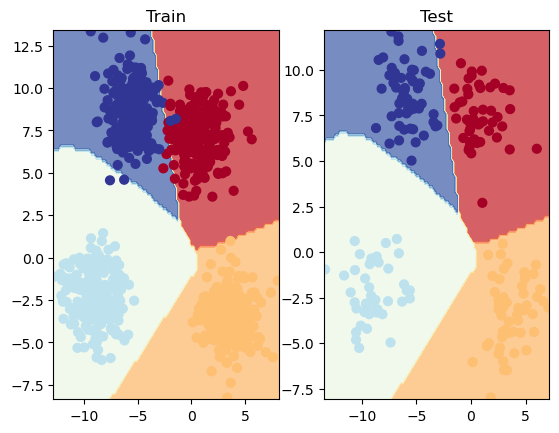

In [61]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [63]:
from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

torchmetrics_accuracy(y_preds, y_blob_test)

tensor(0.9900)